##TASK 2 – Customer Segmentation

Customer segmentation is the process of dividing customers into groups
based on similar characteristics and behavior.

In this task, we use clustering techniques to identify different types
of customers based on their spending patterns. This helps businesses
create targeted marketing strategies.

In [1]:
# This step imports the required libraries for data analysis, visualization, and
# clustering.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# The dataset is loaded to analyze customer demographics and spending behavior.

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# This step helps understand the structure, features, and basic statistics of
# the dataset.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##Basic EDA
Income vs Spending Score

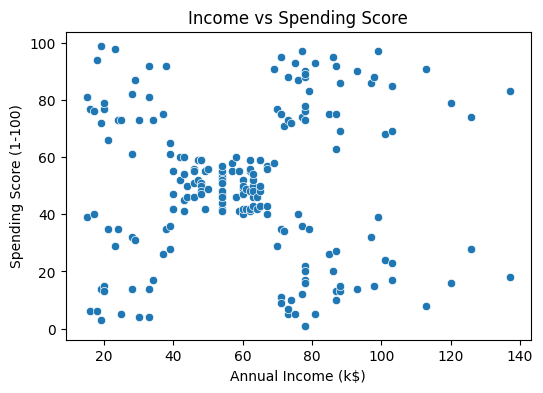

In [4]:
# This visualization shows how income relates to spending behavior.

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

Gender Distribution

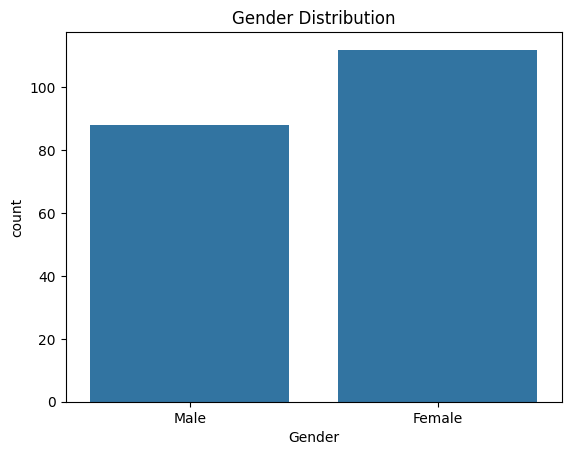

In [5]:
# This shows the distribution of customers based on gender.

sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

##Feature Selection

In [6]:
# We select relevant features for clustering: income and spending score.

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

##Feature Scaling

In [9]:
# Scaling ensures that all features contribute equally to clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

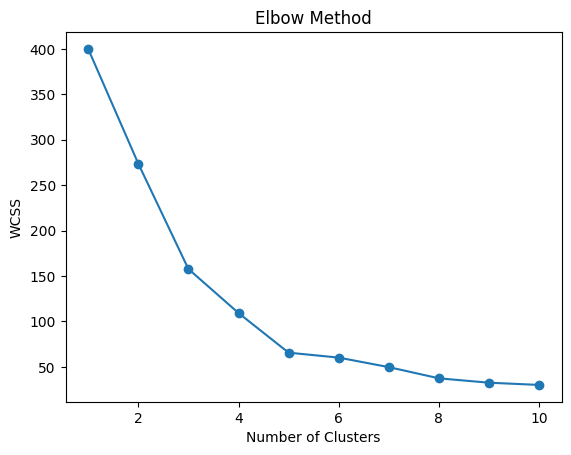

In [11]:
# The elbow method helps determine the optimal number of clusters.

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

##Apply K-Means

In [13]:
# K-Means clustering is applied to segment customers into groups.

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

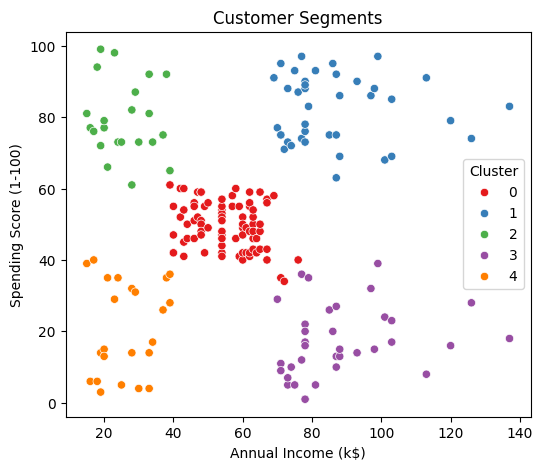

In [14]:
# This visualization shows how customers are grouped based on income and
# spending.

plt.figure(figsize=(6,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df
)

plt.title("Customer Segments")
plt.show()

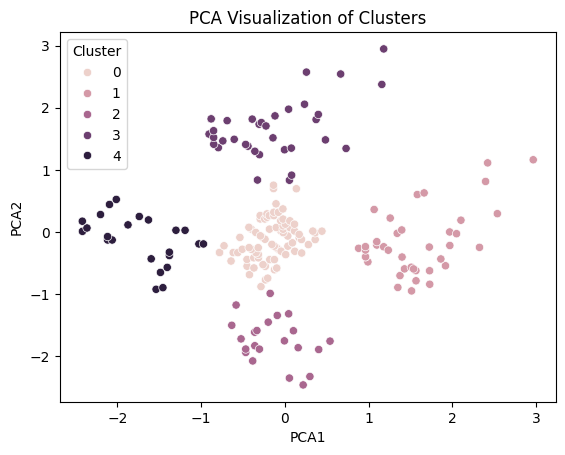

In [15]:
# PCA reduces dimensions to visualize clusters more clearly.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df)
plt.title("PCA Visualization of Clusters")
plt.show()

##Business Strategy

**Cluster 0** – High Income, High Spending:
→ Target with premium products and loyalty programs

**Cluster 1** – Low Income, Low Spending:
→ Offer discounts and budget-friendly options

**Cluster 2** – High Income, Low Spending:
→ Upselling opportunities through marketing campaigns

**Cluster 3** – Low Income, High Spending:
→ Risky segment, needs careful targeting

**Cluster 4** – Average Customers:
→ Maintain engagement with regular offers

##Conclusion
This analysis demonstrates how clustering can segment customers based on behavior.
These insights help businesses design targeted marketing strategies and improve customer engagement.